## Evaluation Priority

1. Recall
2. F1 Score
3. ROC-AUC
4. Accuracy

## SELECTION FOR BEHAVIOUR MODEL

### Experiment 1: Baseline Models Comparison
1. Logistic Regression 
2. Random Forest
3. Gradient Boosting

In [1]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from matplotlib import pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)


In [2]:
# import and load behaviour datasets
X_beh_train = pd.read_csv("../datasets/X_beh_train.csv")
X_beh_val = pd.read_csv("../datasets/X_beh_val.csv")

y_beh_train = pd.read_csv("../datasets/y_beh_train.csv").squeeze()
y_beh_val = pd.read_csv("../datasets/y_beh_val.csv").squeeze()

print(X_beh_train.shape)
print(X_beh_val.shape)
print(y_beh_train.value_counts())

(99, 16)
(34, 16)
risk_label
1    60
0    39
Name: count, dtype: int64


In [3]:
# evaluation function
def evaluate_model(model_name, model, X_train, y_train, X_val, y_val, dataset_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_prob)
    else:
        y_prob = None
        roc_auc = None

    results = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "roc_auc": roc_auc
    }

    print(f"\n=== {dataset_name} - {model_name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, zero_division=0))

    return results, model

In [4]:
# baseline behaviour models
behaviour_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [5]:
behaviour_results = []
trained_behaviour_models = {}

for model_name, model in behaviour_models.items():
    result, trained_model = evaluate_model(
        model_name=model_name,
        model=model,
        X_train=X_beh_train,
        y_train=y_beh_train,
        X_val=X_beh_val,
        y_val=y_beh_val,
        dataset_name="Behaviour"
    )

    behaviour_results.append(result)
    trained_behaviour_models[model_name] = trained_model


=== Behaviour - Logistic Regression ===
Confusion Matrix:
[[ 7  7]
 [ 3 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.50      0.58        14
           1       0.71      0.85      0.77        20

    accuracy                           0.71        34
   macro avg       0.70      0.68      0.68        34
weighted avg       0.70      0.71      0.69        34


=== Behaviour - Random Forest ===
Confusion Matrix:
[[ 7  7]
 [ 3 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.50      0.58        14
           1       0.71      0.85      0.77        20

    accuracy                           0.71        34
   macro avg       0.70      0.68      0.68        34
weighted avg       0.70      0.71      0.69        34


=== Behaviour - Gradient Boosting ===
Confusion Matrix:
[[ 7  7]
 [ 5 15]]

Classification Report:
              precision    recall  f1-score   su

/opt/anaconda3/envs/dataviz305/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
# compare results 
behaviour_results_df = pd.DataFrame(behaviour_results)

behaviour_results_df.sort_values(
    by=["recall", "f1", "roc_auc"],
    ascending=False
)

,dataset,model,accuracy,precision,recall,f1,roc_auc
0,Behaviour,Logistic Regression,0.705882,0.708333,0.85,0.772727,0.853571
1,Behaviour,Random Forest,0.705882,0.708333,0.85,0.772727,0.808929
2,Behaviour,Gradient Boosting,0.647059,0.681818,0.75,0.714286,0.803571


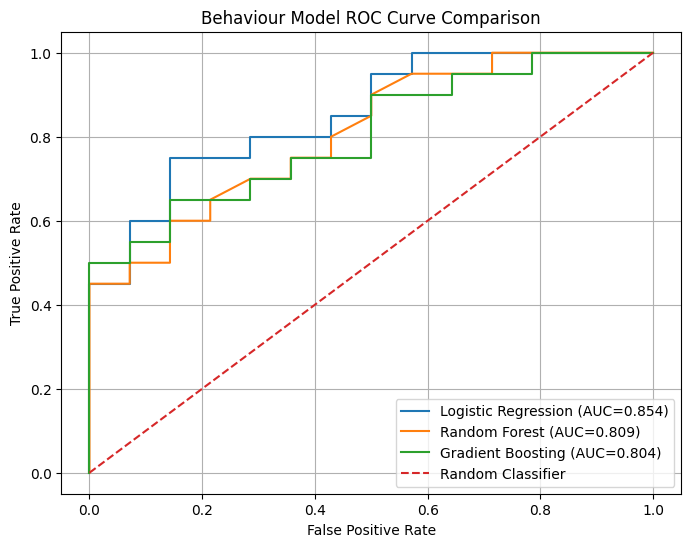

In [7]:
plt.figure(figsize=(8,6))

for model_name, model in trained_behaviour_models.items():

    y_prob = model.predict_proba(X_beh_val)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_beh_val,
        y_prob
    )

    auc_score = roc_auc_score(
        y_beh_val,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Behaviour Model ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
# compare prediction probabilities of the models 
comparison = pd.DataFrame({
    "actual": y_beh_val
})

for name, model in trained_behaviour_models.items():
    comparison[name] = model.predict_proba(X_beh_val)[:, 1]

comparison.head(20)

,actual,Logistic Regression,Random Forest,Gradient Boosting
0,0,0.690385,0.58,0.351747
1,0,0.581878,0.47,0.573082
2,1,0.675572,0.64,0.636335
3,1,0.746630,0.64,0.919074
4,0,0.555209,0.55,0.506309
5,0,0.149497,0.52,0.531964
6,1,0.861861,0.76,0.896741
7,1,0.758894,0.54,0.541078
8,1,0.916873,0.94,0.993069
9,0,0.389475,0.70,0.892693


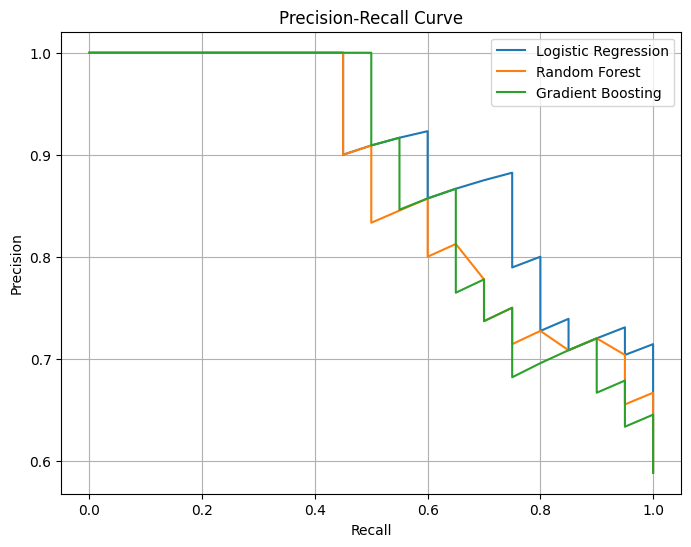

In [9]:
# precision-recall curve 
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name, model in trained_behaviour_models.items():

    y_prob = model.predict_proba(X_beh_val)[:,1]

    precision, recall, _ = precision_recall_curve(
        y_beh_val,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
# feature importance  of LR model
lr = trained_behaviour_models["Logistic Regression"]

importance = pd.DataFrame({
    "feature": X_beh_train.columns,
    "coefficient": lr.coef_[0]
})

importance["abs_coef"] = importance["coefficient"].abs()

importance.sort_values(
    "abs_coef",
    ascending=False
)

,feature,coefficient,abs_coef
14,top_material_type_Lecture Material,0.608670,0.608670
13,top_material_type_Course Page,-0.429110,0.429110
6,weekend_ratio,0.257831,0.257831
12,top_material_type_Assignment,-0.123828,0.123828
15,top_material_type_No Activity,0.121622,0.121622
7,after_hours_ratio,-0.104620,0.104620
11,forum_views,-0.068444,0.068444
9,assignment_views,-0.044685,0.044685
8,lecture_material_views,-0.041618,0.041618
1,active_days,-0.041349,0.041349


In [17]:
# feataure importance of RF model
rf = trained_behaviour_models["Random Forest"]
rf_importance = pd.DataFrame({
    "feature": X_beh_train.columns,
    "importance": rf.feature_importances_
})
rf_importance.sort_values(
    "importance",
    ascending=False
)   

,feature,importance
9,assignment_views,0.109836
6,weekend_ratio,0.099659
1,active_days,0.097892
8,lecture_material_views,0.092088
2,unique_materials,0.078290
3,after_hours_events,0.076464
4,weekend_events,0.076178
0,total_events,0.074648
7,after_hours_ratio,0.073353
11,forum_views,0.068704


In [11]:
# validation predictions table (LR model)
best_model = trained_behaviour_models["Logistic Regression"]

predictions = pd.DataFrame({
    "actual": y_beh_val,
    "predicted": best_model.predict(X_beh_val),
    "risk_probability":
        best_model.predict_proba(X_beh_val)[:,1]
})

predictions.sort_values(
    "risk_probability",
    ascending=False
).head(20)

,actual,predicted,risk_probability
8,1,1,0.916873
29,1,1,0.868879
20,1,1,0.865361
6,1,1,0.861861
16,1,1,0.827936
22,1,1,0.803240
23,1,1,0.798190
10,1,1,0.794719
13,1,1,0.784311
12,0,1,0.772033


In [18]:
# validation prediction table (RF model)
rf_val_preds = rf.predict(X_beh_val)
rf_val_probs = rf.predict_proba(X_beh_val)[:, 1]

rf_val_results = pd.DataFrame({
    "true_label": y_beh_val,
    "pred_label": rf_val_preds,
    "pred_prob": rf_val_probs
})
rf_val_results.sort_values(
    "pred_prob",
    ascending=False
).head(20)

,true_label,pred_label,pred_prob
8,1,1,0.94
20,1,1,0.93
29,1,1,0.91
14,1,1,0.83
16,1,1,0.83
13,1,1,0.79
6,1,1,0.76
23,1,1,0.74
28,1,1,0.72
9,0,1,0.70


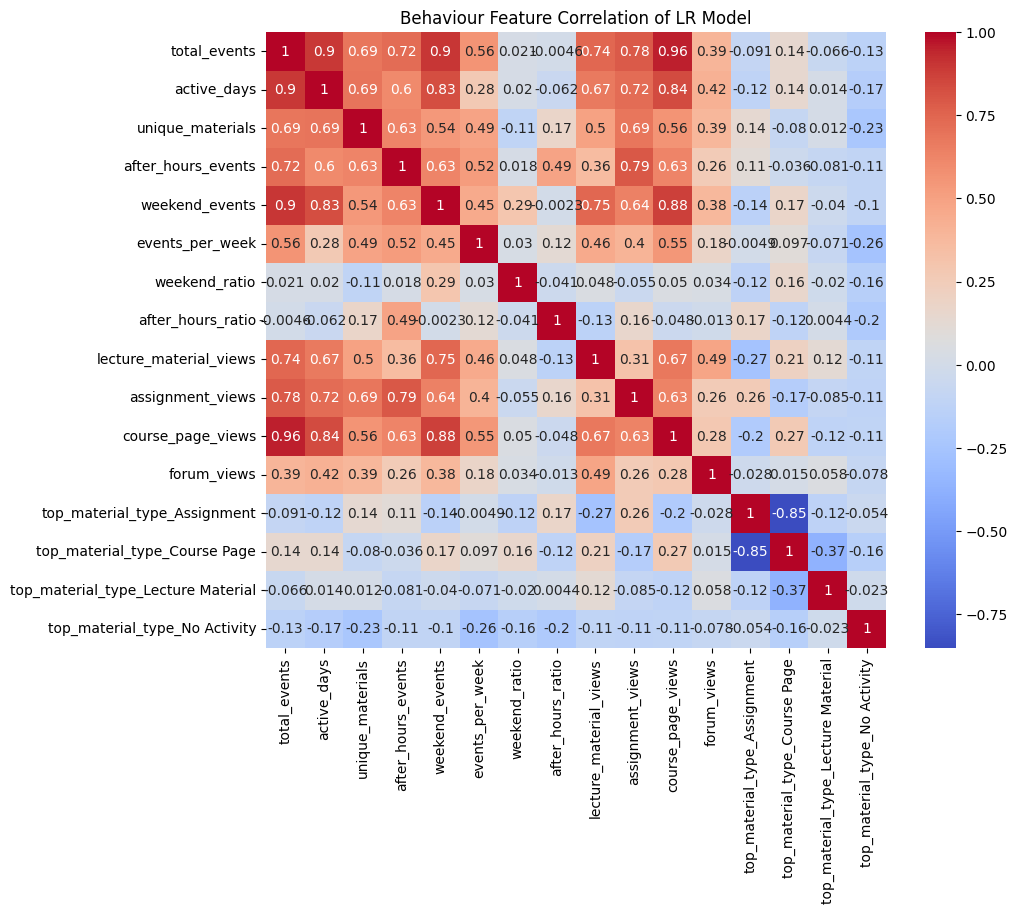

In [19]:
# feature correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    X_beh_train.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Behaviour Feature Correlation of LR Model")

plt.show()

In [13]:
lr = trained_behaviour_models["Logistic Regression"]

coef_df = pd.DataFrame({
    "feature": X_beh_train.columns,
    "coefficient": lr.coef_[0]
})

coef_df.sort_values(
    "coefficient",
    ascending=False
)

,feature,coefficient
14,top_material_type_Lecture Material,0.608670
6,weekend_ratio,0.257831
15,top_material_type_No Activity,0.121622
0,total_events,0.033341
4,weekend_events,0.019561
5,events_per_week,0.007613
3,after_hours_events,0.002094
2,unique_materials,-0.010557
10,course_page_views,-0.031671
1,active_days,-0.041349


In [21]:
lr = trained_behaviour_models["Random Forest"]

coef_df = pd.DataFrame({
    "feature": X_beh_train.columns,
    "importance": lr.feature_importances_
})

coef_df.sort_values(
    "importance",
    ascending=False
)

,feature,importance
9,assignment_views,0.109836
6,weekend_ratio,0.099659
1,active_days,0.097892
8,lecture_material_views,0.092088
2,unique_materials,0.078290
3,after_hours_events,0.076464
4,weekend_events,0.076178
0,total_events,0.074648
7,after_hours_ratio,0.073353
11,forum_views,0.068704


In [14]:
coef_df.sort_values(
    "coefficient",
    ascending=True
)

,feature,coefficient
13,top_material_type_Course Page,-0.429110
12,top_material_type_Assignment,-0.123828
7,after_hours_ratio,-0.104620
11,forum_views,-0.068444
9,assignment_views,-0.044685
8,lecture_material_views,-0.041618
1,active_days,-0.041349
10,course_page_views,-0.031671
2,unique_materials,-0.010557
3,after_hours_events,0.002094


In [15]:
# rebuild snapshot from existing behaviour data
snapshot = pd.concat([X_beh_train, X_beh_val], ignore_index=True).copy()
snapshot["risk_label"] = pd.concat([y_beh_train, y_beh_val], ignore_index=True).values

# recover single top_material_type from one-hot columns
material_cols = [c for c in snapshot.columns if c.startswith("top_material_type_")]
snapshot["top_material_type"] = (
    snapshot[material_cols]
    .idxmax(axis=1)
    .str.replace("top_material_type_", "", regex=False)
)

pd.crosstab(
    snapshot["top_material_type"],
    snapshot["risk_label"],
    normalize="index"
)

risk_label,0,1
top_material_type,,
Assignment,0.500000,0.500000
Course Page,0.380435,0.619565
Lecture Material,0.285714,0.714286
No Activity,0.000000,1.000000
